# Symmetric Conditional Gaussian Mixture in 2D

This notebook revisits the scalar $\mathbb{C}_2$-symmetric conditional Gaussian mixture from Appendix G.1 of the paper. In this model the Pointwise Mutual Dependency (PMD)
\[
    \kappa(x, y) = \frac{p_{XY}(x, y)}{p_X(x)\,p_Y(y)}
\]
is available in closed form. Following Section 2, this kernel defines the conditional expectation operator, so the approximation error can be inspected directly rather than only through downstream predictions.

The two-dimensional setting makes $p_{XY}(x, y)$, $p_X(x)p_Y(y)$, $\kappa(x, y)$, and $x \mapsto \mathbb{E}[Y \mid X=x]$ visible on a common domain. Four estimators are compared: eNCP, NCP, iDRF, and DRF. Checkpoints are loaded when present and otherwise trained with the notebook hyperparameters.

## Outline

1. Construct the scalar $\mathbb{C}_2$-symmetric cGMM and four dataset sizes.
2. Visualize the analytic surfaces $p_{XY}(x, y)$, $p_X(x)p_Y(y)$, and $\kappa(x, y)$.
3. Train or load eNCP, NCP, iDRF, and DRF with one checkpoint convention.
4. Compare the stored training and validation curves.
5. Measure sample efficiency under a shared product test distribution.
6. Compare the analytic conditional expectation with the eNCP and NCP reconstructions.
7. Compare absolute PMD error maps on a common color scale.
8. Compare the learned PMD surfaces with the analytic PMD on the largest training split.


In [48]:
%load_ext autoreload
%autoreload 2

from __future__ import annotations

import pathlib
import sys
import warnings

ROOT = pathlib.Path.cwd()

def find_repo_root(start: pathlib.Path) -> pathlib.Path:
    for candidate in [start, *start.parents]:
        if (candidate / '.git').exists():
            return candidate
    raise FileNotFoundError('Could not find the repository root from the notebook location.')

WS_PATH = find_repo_root(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(WS_PATH) not in sys.path:
    sys.path.insert(0, str(WS_PATH))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from plotting import (
    plot_conditional_expectation_grid,
    plot_jointgrid_triptych,
    plot_pmd_error_grid,
    plot_pmd_surface_grid,
    plot_sample_efficiency_grid,
    plot_saved_training_curves_grid,
)
from utils import (
    VAL_METRIC,
    build_c2_scalar_gmm,
    build_checkpoint_paths_by_size,
    build_dataset_bundle,
    build_pmd_model,
    build_product_support_domain_from_samples,
    compute_conditional_expectation_curve,
    compute_density_reference_grid,
    compute_pmd_error_grid,
    draw_joint_and_product_samples,
    estimate_expected_pmd_error,
    fit_conditional_expectation_decoder,
    fit_or_load_pmd_model,
)

from paper.experiments.symmetricGMM.plot_utils import (
    plot_analytic_joint_2D,
    plot_analytic_pmd_2D,
    plot_analytic_prod_2D,
)

CHECKPOINT_DIR = ROOT / 'checkpoints'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 10
GMM_SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_float32_matmul_precision('medium')

plt.style.use('seaborn-v0_8-notebook')
sns.set_context('notebook')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Scalar $\mathbb{C}_2$-symmetric dataset

We work with scalar random variables $X, Y \in \mathbb{R}$ and the non-trivial action of $\mathbb{C}_2 = \{e, g_r\}$ given by $g_r \triangleright x = -x$ and $g_r \triangleright y = -y$. As in Appendix G.1, the joint law is obtained by symmetrizing a Gaussian mixture over the group orbit. The tables below summarize the resulting problem instance and the four dataset sizes used in the sample-efficiency study.

In [49]:
SYMM_GROUP = 'C2'
N_KERNELS = 15
MEANS_MAX_NORM = 1.0
MAX_TOTAL_SAMPLES = 20_000
TOTAL_SAMPLE_SIZES = [2_000, 6_000, 12_000, 20_000]
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

BATCH_SIZE = 2048
PAIRWISE_BATCH_SIZE = 2048

if TOTAL_SAMPLE_SIZES[-1] != MAX_TOTAL_SAMPLES:
    raise ValueError('The final entry in TOTAL_SAMPLE_SIZES must match MAX_TOTAL_SAMPLES.')

setup = build_c2_scalar_gmm(
    n_kernels=N_KERNELS,
    means_max_norm=MEANS_MAX_NORM,
    sampling_seed=SEED,
    gmm_seed=GMM_SEED,
)
dataset_bundles = {
    n_total_samples: build_dataset_bundle(
        gmm=setup.gmm,
        rep_x=setup.rep_x,
        rep_y=setup.rep_y,
        n_total_samples=n_total_samples,
        train_ratio=TRAIN_RATIO,
        val_ratio=VAL_RATIO,
        batch_size=BATCH_SIZE,
        pairwise_batch_size=PAIRWISE_BATCH_SIZE,
    )
    for n_total_samples in TOTAL_SAMPLE_SIZES
}
reference_dataset = dataset_bundles[MAX_TOTAL_SAMPLES]

problem_summary = pd.DataFrame(
    {
        'value': [
            SYMM_GROUP,
            setup.G.order(),
            setup.rep_x.size,
            setup.rep_y.size,
            N_KERNELS,
            setup.gmm.n_kernels,
            MEANS_MAX_NORM,
            float(reference_dataset.x_std.squeeze()),
            float(reference_dataset.y_std.squeeze()),
            float(setup.gmm.MI(reference_dataset.x.numpy(), reference_dataset.y.numpy())),
        ]
    },
    index=[
        'symmetry group $\\mathbb{G}$',
        'group order $|\\mathbb{G}|$',
        '$\\dim(\\mathcal{X})$',
        '$\\dim(\\mathcal{Y})$',
        'base Gaussian components',
        'components after symmetrization',
        '$\\|\\mu\\|_{\\max}$',
        'standard deviation of $X$',
        'standard deviation of $Y$',
        'estimated mutual information',
    ],
)
display(problem_summary.round(4))

sample_schedule = pd.DataFrame(
    [
        {
            '$N$': n_total_samples,
            '$|\\mathcal{D}_{\\mathrm{train}}|$': len(bundle.x_train),
            '$|\\mathcal{D}_{\\mathrm{val}}|$': len(bundle.x_val),
            '$|\\mathcal{D}_{\\mathrm{test}}|$': len(bundle.x_test),
        }
        for n_total_samples, bundle in dataset_bundles.items()
    ]
)
display(sample_schedule)

,value
symmetry group $\mathbb{G}$,C2
group order $|\mathbb{G}|$,2
$\dim(\mathcal{X})$,1
$\dim(\mathcal{Y})$,1
base Gaussian components,15
components after symmetrization,30
$\|\mu\|_{\max}$,1.0
standard deviation of $X$,0.690975
standard deviation of $Y$,0.626669
estimated mutual information,0.229715


,$N$,$|\mathcal{D}_{\mathrm{train}}|$,$|\mathcal{D}_{\mathrm{val}}|$,$|\mathcal{D}_{\mathrm{test}}|$
0,2000,1400,300,300
1,6000,4200,900,900
2,12000,8400,1800,1800
3,20000,14000,3000,3000


## 2. Analytic $p_{XY}$, $p_Xp_Y$, and $\kappa$

Section 2 defines the PMD $\kappa$ as the Radon-Nikodym derivative of the joint law with respect to the product of marginals. The triptych below shows the corresponding analytic surfaces for this cGMM: the joint density $p_{XY}(x, y)$, the product density $p_X(x)p_Y(y)$, and the PMD $\kappa(x, y)$. The figures are rendered directly from the matplotlib objects returned by [plot_utils.py](/home/danfoa/Projects/symm_rep_learn/paper/experiments/symmetricGMM/plot_utils.py), so rerunning the cell updates the display after any parameter change.

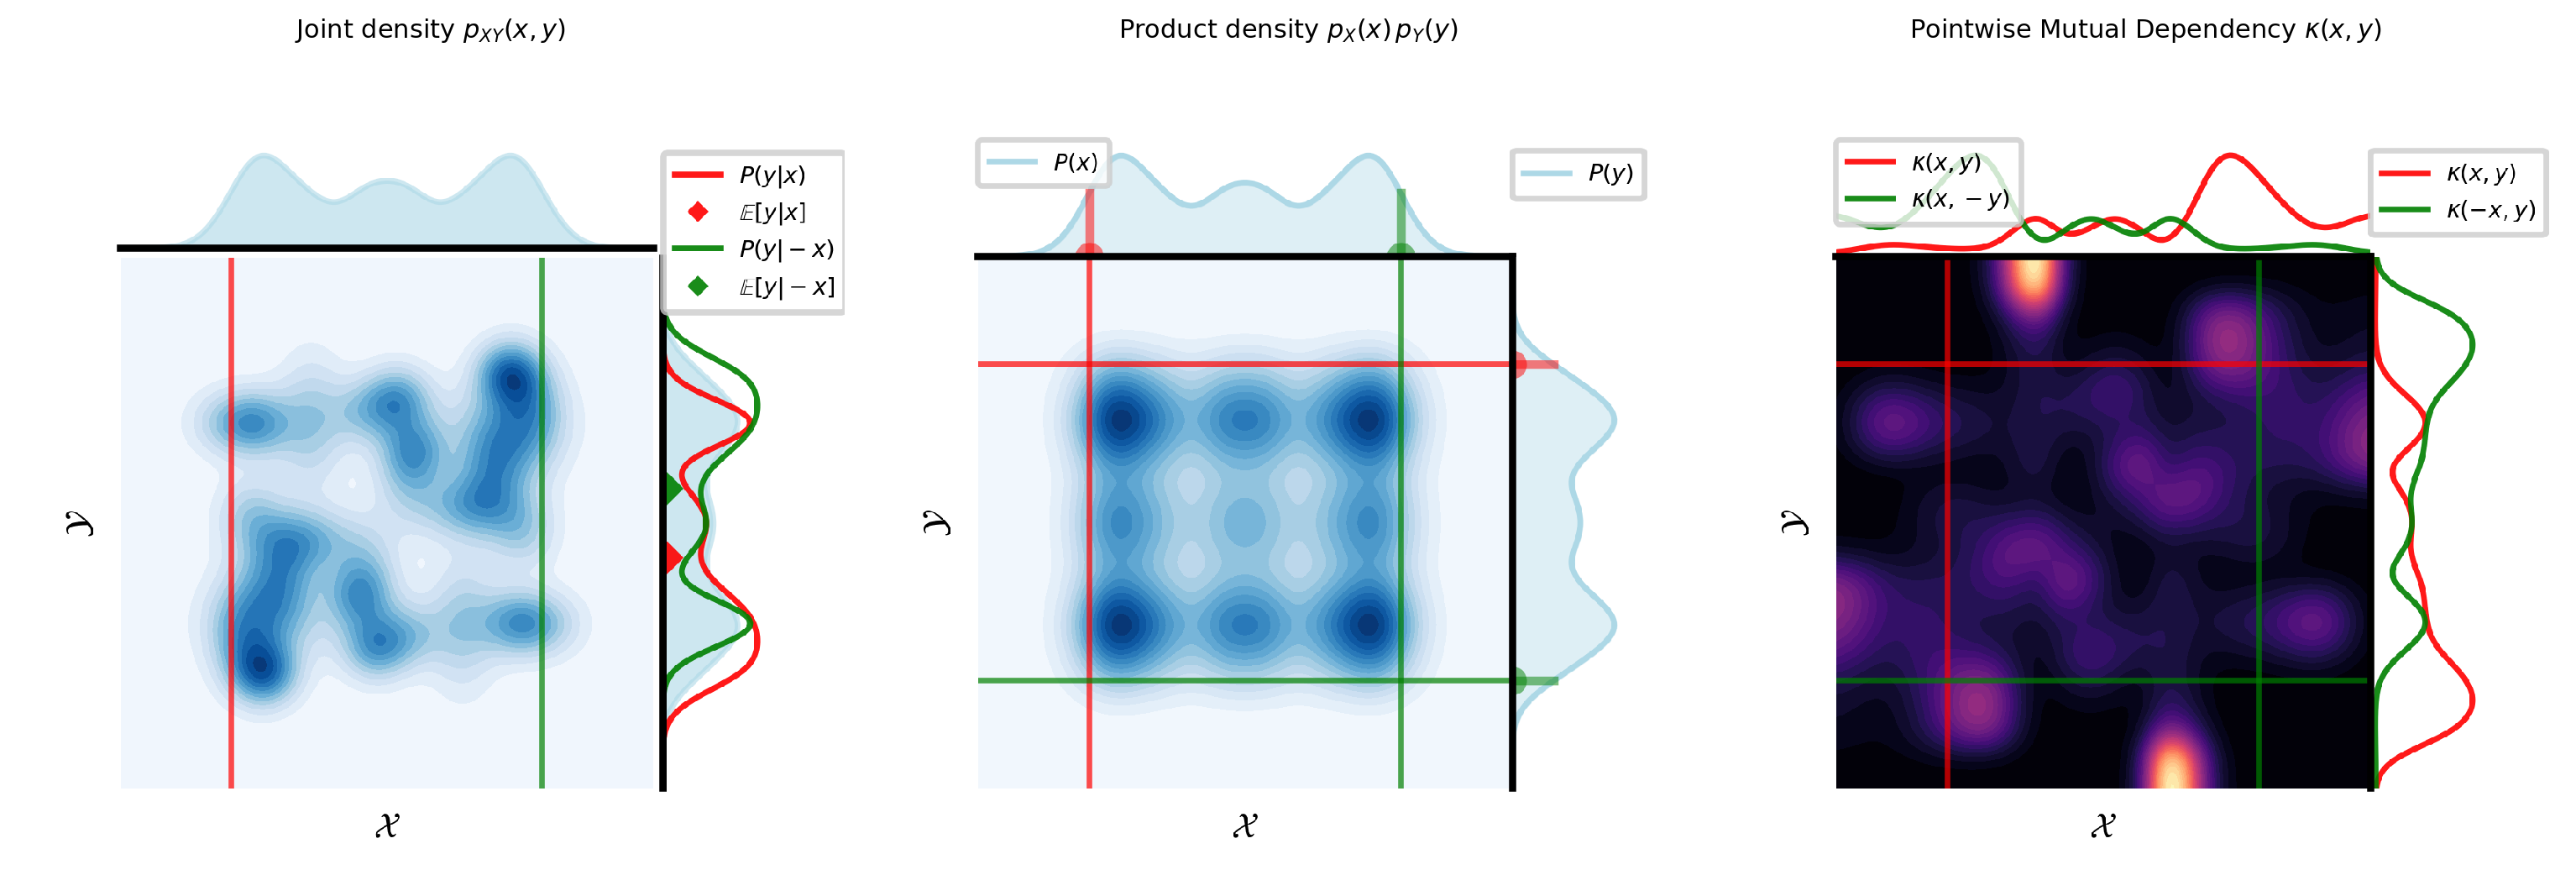

In [50]:
analytic_items = [
    (
        r'Joint density $p_{XY}(x, y)$',
        lambda: plot_analytic_joint_2D(
            setup.gmm,
            G=setup.G,
            rep_X=setup.rep_x,
            rep_Y=setup.rep_y,
            x_samples=reference_dataset.x.numpy(),
            y_samples=reference_dataset.y.numpy(),
            show_orbit_guides=True,
        ),
    ),
    (
        r'Product density $p_X(x)\,p_Y(y)$',
        lambda: plot_analytic_prod_2D(
            setup.gmm,
            G=setup.G,
            rep_X=setup.rep_x,
            rep_Y=setup.rep_y,
            x_samples=reference_dataset.x.numpy(),
            y_samples=reference_dataset.y.numpy(),
            show_orbit_guides=True,
        ),
    ),
    (
        r'Pointwise Mutual Dependency $\kappa(x, y)$',
        lambda: plot_analytic_pmd_2D(
            setup.gmm,
            G=setup.G,
            rep_X=setup.rep_x,
            rep_Y=setup.rep_y,
            x_samples=reference_dataset.x.numpy(),
            y_samples=reference_dataset.y.numpy(),
            show_orbit_guides=True,
        ),
    ),
]

with warnings.catch_warnings():
    warnings.filterwarnings('ignore', message='Tight layout not applied.*', category=UserWarning)
    fig_triptych, axes_triptych = plot_jointgrid_triptych(analytic_items)
plt.show()

## 3. Four estimators of $\kappa$

The hidden cell below iterates over the four dataset sizes and the four estimators. eNCP and NCP learn finite-rank models of the conditional expectation operator, while iDRF and DRF fit $\widehat{\kappa}$ directly. All checkpoints follow the same naming rule: if a checkpoint is present it is loaded, otherwise the model is trained, saved, and its training curve is exported.

In [51]:
MODEL_ORDER = ['eNCP', 'NCP', 'iDRF', 'DRF']
EMBEDDING_DIM = 24
HIDDEN_UNITS = 64
HIDDEN_LAYERS = 3
ACTIVATION = 'ELU'
ORTH_REG = 0.01
CENTERING_REG = 0.01
MOMENTUM = 0.95
LEARNING_RATE = 1e-3
TRAIN_EPOCHS = 1000
CHECK_EVERY = 5
EARLY_STOP_EPOCHS = 500
PATIENCE = EARLY_STOP_EPOCHS // CHECK_EVERY
PLOT_FREQ = 10
MONTE_CARLO_EVAL_MULTIPLIER = 2
ERROR_GRID_SIZE = 180
ERROR_SUPPORT_QUANTILE = 0.99
ERROR_DOMAIN_USES_EXTREMA = False
MAX_TRAIN_SAMPLES = len(reference_dataset.x_train)
SHARED_TEST_SAMPLES_PER_DISTRIBUTION = MONTE_CARLO_EVAL_MULTIPLIER * MAX_TRAIN_SAMPLES

training_config = pd.DataFrame(
    {
        'value': [
            EMBEDDING_DIM,
            HIDDEN_UNITS,
            HIDDEN_LAYERS,
            ACTIVATION,
            ORTH_REG,
            CENTERING_REG,
            MOMENTUM,
            LEARNING_RATE,
            TRAIN_EPOCHS,
            CHECK_EVERY,
            EARLY_STOP_EPOCHS,
            PATIENCE,
            PLOT_FREQ,
            MONTE_CARLO_EVAL_MULTIPLIER,
            MAX_TRAIN_SAMPLES,
            SHARED_TEST_SAMPLES_PER_DISTRIBUTION,
            ERROR_GRID_SIZE,
            ERROR_SUPPORT_QUANTILE,
            ERROR_DOMAIN_USES_EXTREMA,
            BATCH_SIZE,
            PAIRWISE_BATCH_SIZE,
        ]
    },
    index=[
        'embedding dimension',
        'hidden units',
        'hidden layers',
        'activation',
        'orthogonality penalty',
        'centering penalty',
        'momentum',
        'learning rate',
        'training epochs',
        'validation cadence',
        'early-stop patience (epochs)',
        'early-stop patience (checks)',
        'curve sampling cadence',
        'Monte Carlo multiplier',
        '$|\\mathcal{D}_{\\mathrm{train}}^{\\max}|$',
        'shared test pairs per distribution',
        'grid resolution',
        'product-support quantile',
        'use empirical extrema',
        'batch size',
        'pairwise batch size',
    ],
)
display(training_config)

fit_schedule = pd.DataFrame(
    [
        {
            '$N$': n_total_samples,
            '$|\\mathcal{D}_{\\mathrm{train}}|$': len(bundle.x_train),
            '$|\\mathcal{D}_{\\mathrm{val}}|$': len(bundle.x_val),
            '$|\\mathcal{D}_{\\mathrm{test}}|$': len(bundle.x_test),
            'shared test pairs per distribution': SHARED_TEST_SAMPLES_PER_DISTRIBUTION,
        }
        for n_total_samples, bundle in dataset_bundles.items()
    ]
)
display(fit_schedule)

,value
embedding dimension,24
hidden units,64
hidden layers,3
activation,ELU
orthogonality penalty,0.01
centering penalty,0.01
momentum,0.95
learning rate,0.001
training epochs,1000
validation cadence,5


,$N$,$|\mathcal{D}_{\mathrm{train}}|$,$|\mathcal{D}_{\mathrm{val}}|$,$|\mathcal{D}_{\mathrm{test}}|$,shared test pairs per distribution
0,2000,1400,300,300,28000
1,6000,4200,900,900,28000
2,12000,8400,1800,1800,28000
3,20000,14000,3000,3000,28000


In [52]:
trained_models_by_size = {}
checkpoint_paths_by_size = build_checkpoint_paths_by_size(
    checkpoint_dir=CHECKPOINT_DIR,
    model_order=MODEL_ORDER,
    sample_sizes=TOTAL_SAMPLE_SIZES,
    n_kernels=N_KERNELS,
    means_max_norm=MEANS_MAX_NORM,
    seed=SEED,
)
row_labels = {
    n_total_samples: f"N_train = {len(dataset_bundles[n_total_samples].x_train):,}"
    for n_total_samples in TOTAL_SAMPLE_SIZES
}

for n_total_samples in TOTAL_SAMPLE_SIZES:
    dataset = dataset_bundles[n_total_samples]
    train_samples = len(dataset.x_train)
    trained_models_by_size[n_total_samples] = {}

    for model_name in MODEL_ORDER:
        torch.manual_seed(SEED)
        model = build_pmd_model(
            model_name,
            rep_x=setup.rep_x,
            rep_y=setup.rep_y,
            embedding_dim=EMBEDDING_DIM,
            hidden_units=HIDDEN_UNITS,
            hidden_layers=HIDDEN_LAYERS,
            activation=ACTIVATION,
            orth_reg=ORTH_REG,
            centering_reg=CENTERING_REG,
            momentum=MOMENTUM,
        )
        optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

        uses_pairwise_loader = model_name in {'DRF', 'iDRF'}
        train_loader = dataset.pairwise_train_loader if uses_pairwise_loader else dataset.train_loader
        val_loader = dataset.pairwise_val_loader if uses_pairwise_loader else dataset.val_loader
        checkpoint_path = checkpoint_paths_by_size[n_total_samples][model_name]

        fit_or_load_pmd_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            optimizer=optimizer,
            checkpoint_path=checkpoint_path,
            train_epochs=TRAIN_EPOCHS,
            check_every=CHECK_EVERY,
            patience=PATIENCE,
            plot_freq=PLOT_FREQ,
            desc=f'{model_name}, N={n_total_samples:,}',
            plot_title=f'{model_name}, train={train_samples:,}: train/val {VAL_METRIC}',
            val_metric=VAL_METRIC,
            checkpoint_meta={
                'seed': SEED,
                'n_total_samples': n_total_samples,
                'train_samples': train_samples,
                'val_samples': len(dataset.x_val),
                'test_samples': len(dataset.x_test),
                'n_kernels': N_KERNELS,
                'means_max_norm': MEANS_MAX_NORM,
            },
            enable_plots=False,
            store_curve=True,
            load_checkpoint_if_available=True,
            save_checkpoint_on_improve=True,
            show_curve_on_load=False,
            force_retrain=False,
        )
        trained_models_by_size[n_total_samples][model_name] = model.eval()

Loading model from checkpoint: /home/danfoa/Projects/symm_rep_learn/paper/examples/cGMM_2D/checkpoints/encp_nk=15_norm=1p00_N=2000_seed=10.pth
Loaded - best val objective: -0.18089
Loading model from checkpoint: /home/danfoa/Projects/symm_rep_learn/paper/examples/cGMM_2D/checkpoints/ncp_nk=15_norm=1p00_N=2000_seed=10.pth
Loaded - best val objective: -0.14153
Loading model from checkpoint: /home/danfoa/Projects/symm_rep_learn/paper/examples/cGMM_2D/checkpoints/idrf_nk=15_norm=1p00_N=2000_seed=10.pth
Loaded - best val objective: -0.17461
Loading model from checkpoint: /home/danfoa/Projects/symm_rep_learn/paper/examples/cGMM_2D/checkpoints/drf_nk=15_norm=1p00_N=2000_seed=10.pth
Loaded - best val objective: -0.12781
Loading model from checkpoint: /home/danfoa/Projects/symm_rep_learn/paper/examples/cGMM_2D/checkpoints/encp_nk=15_norm=1p00_N=6000_seed=10.pth
Loaded - best val objective: -0.16452
Loading model from checkpoint: /home/danfoa/Projects/symm_rep_learn/paper/examples/cGMM_2D/checkp

## 4. Stored training curves

Rows correspond to increasing training size $|\mathcal{D}_{\mathrm{train}}|$ and columns correspond to eNCP, NCP, iDRF, and DRF. Each panel shows the stored training and validation traces for the checkpoint used later in the comparisons.

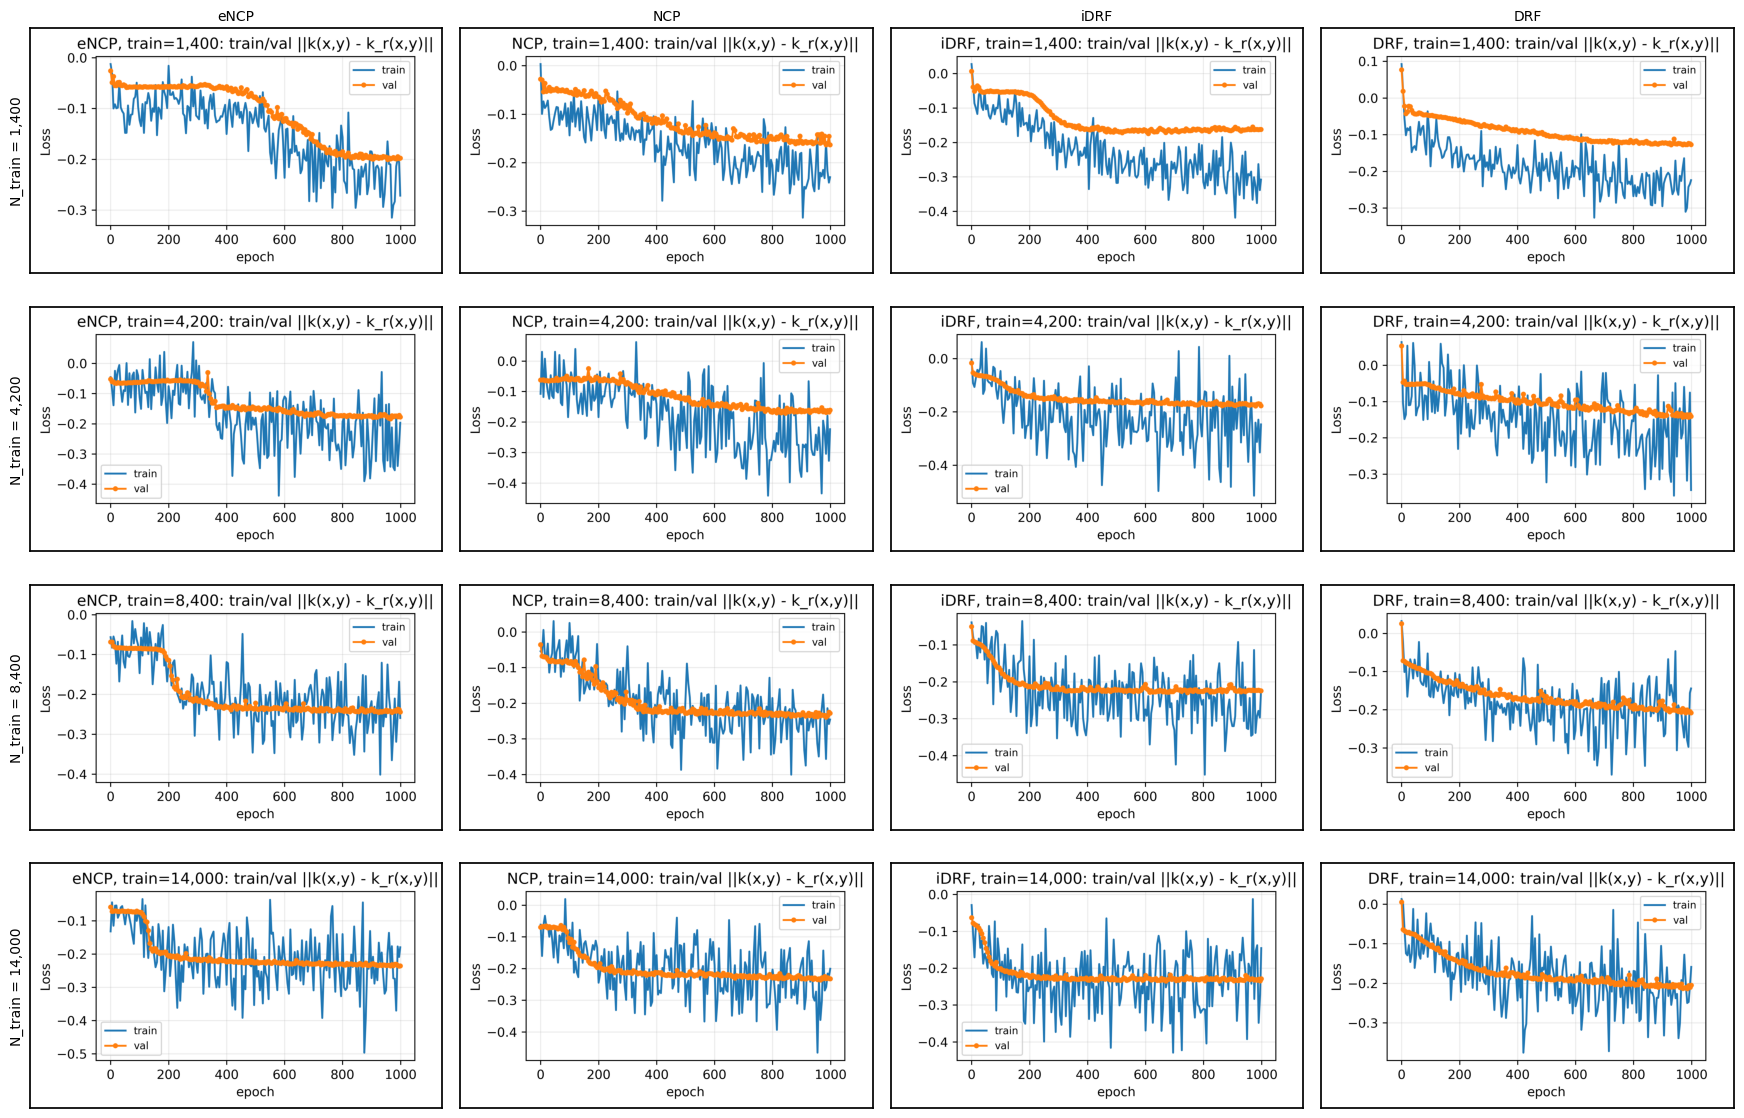

In [53]:
fig_curves, axes_curves = plot_saved_training_curves_grid(
    checkpoint_paths_by_size,
    size_order=TOTAL_SAMPLE_SIZES,
    model_order=MODEL_ORDER,
    row_labels=row_labels,
    figsize=(4.4 * len(MODEL_ORDER), 2.9 * len(TOTAL_SAMPLE_SIZES)),
)
plt.show()

## 5. Sample efficiency under $P_X \otimes P_Y$

One fresh draw from $P_{XY}$ and one fresh draw from $P_X \otimes P_Y$ are generated once and reused throughout the notebook. Each draw contains $2|\mathcal{D}_{\mathrm{train}}^{\max}|$ pairs. The figure below plots
\[
    \mathbb{E}_{(X, Y) \sim P_X \otimes P_Y}\!\left[\,|\kappa(X, Y) - \widehat{\kappa}(X, Y)|\,\right]
\]
as a function of the training-set size.


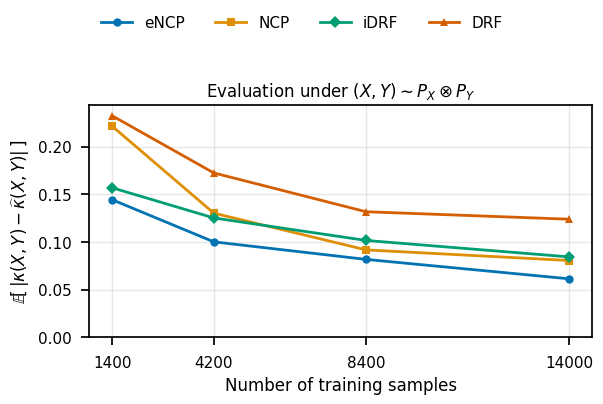

In [54]:
shared_test_samples = draw_joint_and_product_samples(
    gmm=setup.gmm,
    n_joint=SHARED_TEST_SAMPLES_PER_DISTRIBUTION,
    n_product=SHARED_TEST_SAMPLES_PER_DISTRIBUTION,
)

evaluation_rows = []
for n_total_samples in TOTAL_SAMPLE_SIZES:
    dataset = dataset_bundles[n_total_samples]
    for model_name in MODEL_ORDER:
        metrics = estimate_expected_pmd_error(
            gmm=setup.gmm,
            model=trained_models_by_size[n_total_samples][model_name],
            x_mean=dataset.x_mean,
            y_mean=dataset.y_mean,
            x_std=dataset.x_std,
            y_std=dataset.y_std,
            evaluation_samples=shared_test_samples,
        )
        evaluation_rows.append(
            {
                'n_total_samples': n_total_samples,
                'train_samples': len(dataset.x_train),
                'model': model_name,
            }
            | metrics
        )

results_df = pd.DataFrame(evaluation_rows)
results_df['model'] = pd.Categorical(results_df['model'], categories=MODEL_ORDER, ordered=True)
results_df = results_df.sort_values(['n_total_samples', 'model']).reset_index(drop=True)

fig_efficiency, axes_efficiency = plot_sample_efficiency_grid(
    results_df,
    model_order=MODEL_ORDER,
    panels=('product',),
    figsize=(6.2, 3.8),
)


## 6. Conditional expectation $x \mapsto \mathbb{E}[Y \mid X=x]$

Under the symmetry priors, Appendix D shows that the conditional expectation is $\mathbb{G}$-equivariant. The panels below compare the analytic map $x \mapsto \mathbb{E}[Y \mid X=x]$ with the reconstructions induced by eNCP and NCP on the largest training split. DRF and iDRF are omitted in this section because they estimate the PMD $\kappa(x, y)$ directly, but they do not provide the learned conditional representation and decoder needed to reconstruct a regression rule for $x \mapsto \mathbb{E}[Y \mid X=x]$. The shared Cartesian window is built from the common product test draw through the central 99\% coordinate-wise quantile box, or through the empirical extrema when `ERROR_DOMAIN_USES_EXTREMA = True`. The top and side marginals remain the exact $p_X(x)$ and $p_Y(y)$ of the cGMM.


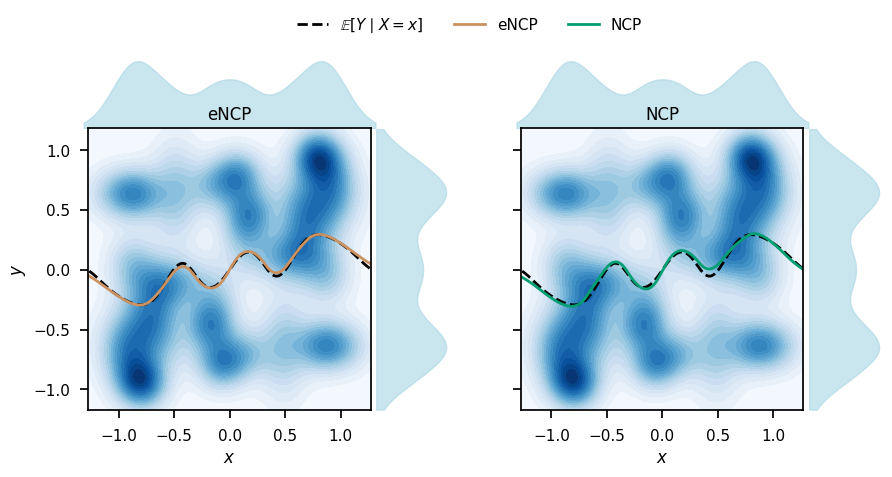

In [55]:
reference_domain = build_product_support_domain_from_samples(
    x_product=shared_test_samples['x_product'],
    y_product=shared_test_samples['y_product'],
    grid_size=ERROR_GRID_SIZE,
    support_quantile=ERROR_SUPPORT_QUANTILE,
    use_extrema=ERROR_DOMAIN_USES_EXTREMA,
)
reference_density_grid = compute_density_reference_grid(
    gmm=setup.gmm,
    G=setup.G,
    domain=reference_domain,
)

reference_models = trained_models_by_size[MAX_TOTAL_SAMPLES]
encp_decoder = fit_conditional_expectation_decoder(
    model=reference_models['eNCP'],
    y_train_c=reference_dataset.y_train_c,
    rep_y=setup.rep_y,
)
ncp_decoder = fit_conditional_expectation_decoder(
    model=reference_models['NCP'],
    y_train_c=reference_dataset.y_train_c,
    rep_y=setup.rep_y,
)

encp_conditional_curve = compute_conditional_expectation_curve(
    gmm=setup.gmm,
    model=reference_models['eNCP'],
    decoder=encp_decoder,
    domain=reference_domain,
    x_mean=reference_dataset.x_mean,
    y_mean=reference_dataset.y_mean,
    x_std=reference_dataset.x_std,
    y_std=reference_dataset.y_std,
)
ncp_conditional_curve = compute_conditional_expectation_curve(
    gmm=setup.gmm,
    model=reference_models['NCP'],
    decoder=ncp_decoder,
    domain=reference_domain,
    x_mean=reference_dataset.x_mean,
    y_mean=reference_dataset.y_mean,
    x_std=reference_dataset.x_std,
    y_std=reference_dataset.y_std,
)

conditional_panel_specs = [
    {
        'title': 'eNCP',
        'x_values': encp_conditional_curve['x_values'],
        'ground_truth': encp_conditional_curve['ground_truth'],
        'prediction': encp_conditional_curve['prediction'],
        'prediction_label': 'eNCP',
        'prediction_color': sns.color_palette('colorblind')[5],
    },
    {
        'title': 'NCP',
        'x_values': ncp_conditional_curve['x_values'],
        'ground_truth': ncp_conditional_curve['ground_truth'],
        'prediction': ncp_conditional_curve['prediction'],
        'prediction_label': 'NCP',
        'prediction_color': sns.color_palette('colorblind')[2],
    },
]

fig_conditional = plot_conditional_expectation_grid(
    reference_density_grid,
    conditional_panel_specs,
    figsize=(8.6, 4.3),
)
plt.show()


## 7. Absolute PMD error $|\kappa - \widehat{\kappa}|$

Each panel below evaluates
\[
    |\kappa(x, y) - \widehat{\kappa}(x, y)|
\]
on a common Cartesian grid over the support window induced by the shared product test draw. All sixteen panels use the same colorbar range, so spatial error patterns are directly comparable across both $|\mathcal{D}_{\mathrm{train}}|$ and the estimator family.


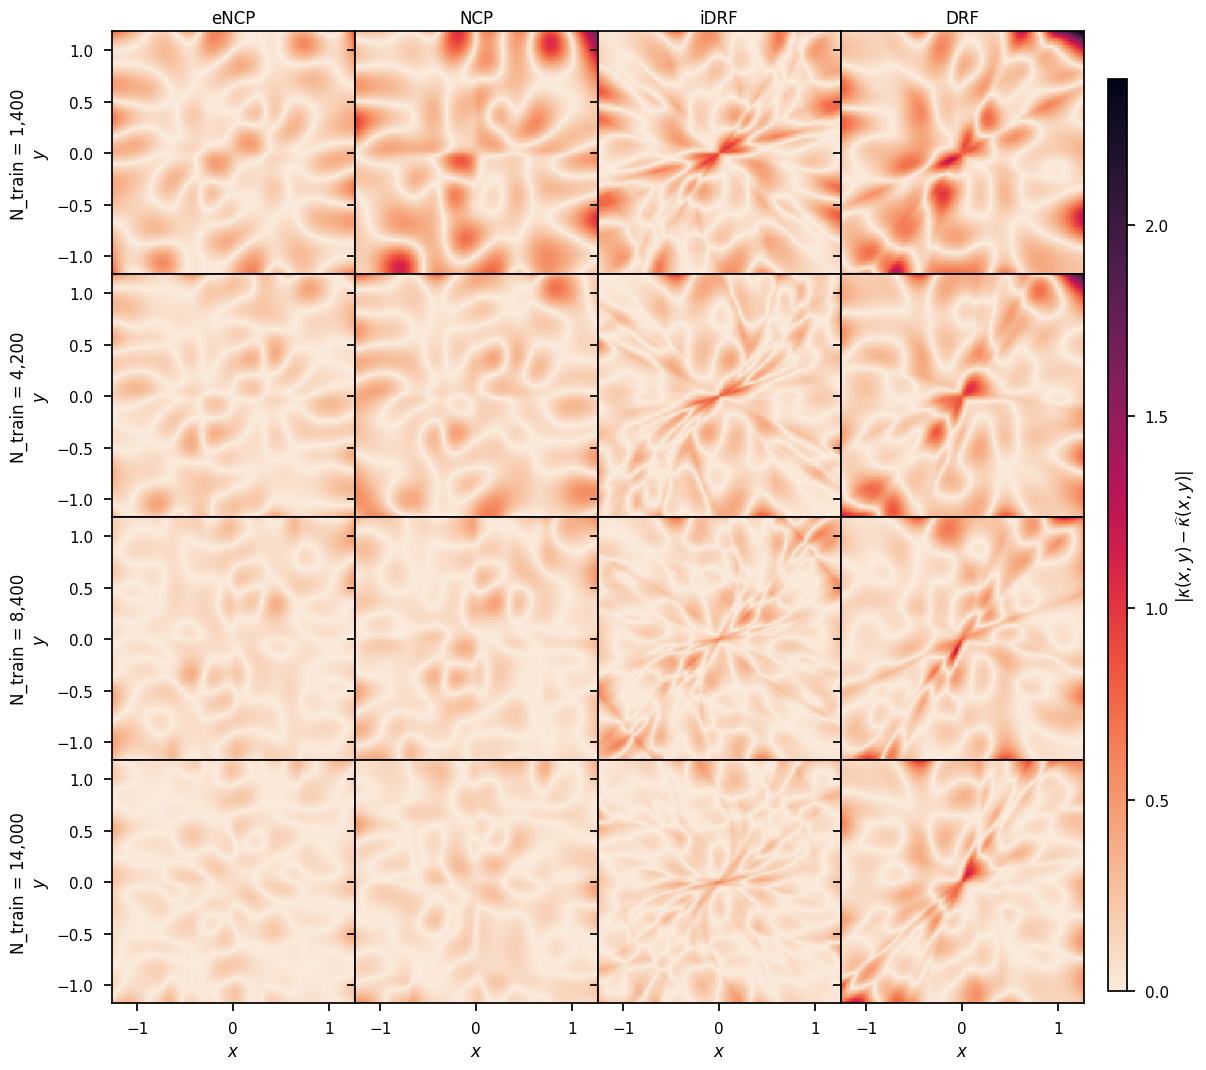

In [58]:
error_grids_by_size = {
    n_total_samples: {
        model_name: compute_pmd_error_grid(
            gmm=setup.gmm,
            model=trained_models_by_size[n_total_samples][model_name],
            G=setup.G,
            domain=reference_domain,
            x_mean=dataset_bundles[n_total_samples].x_mean,
            y_mean=dataset_bundles[n_total_samples].y_mean,
            x_std=dataset_bundles[n_total_samples].x_std,
            y_std=dataset_bundles[n_total_samples].y_std,
            x_product=shared_test_samples['x_product'],
            y_product=shared_test_samples['y_product'],
            support_quantile=ERROR_SUPPORT_QUANTILE,
            apply_density_mask=False,
        )
        for model_name in MODEL_ORDER
    }
    for n_total_samples in TOTAL_SAMPLE_SIZES
}

fig_error, axes_error, error_scale = plot_pmd_error_grid(
    error_grids_by_size,
    size_order=TOTAL_SAMPLE_SIZES,
    model_order=MODEL_ORDER,
    row_labels=row_labels,
    figsize=(3.0 * len(MODEL_ORDER), 3 * len(TOTAL_SAMPLE_SIZES)),
)
plt.show()


## 8. Learned $\widehat{\kappa}$ versus analytic $\kappa$

The PMD surface comparison is shown only for the largest training split. Cross-size behaviour is already summarized by the absolute PMD error maps above. The first column shows the analytic PMD $\kappa(x, y)$, and the remaining columns show the learned surfaces $\widehat{\kappa}(x, y)$ for eNCP, NCP, iDRF, and DRF on the same grid and color scale.


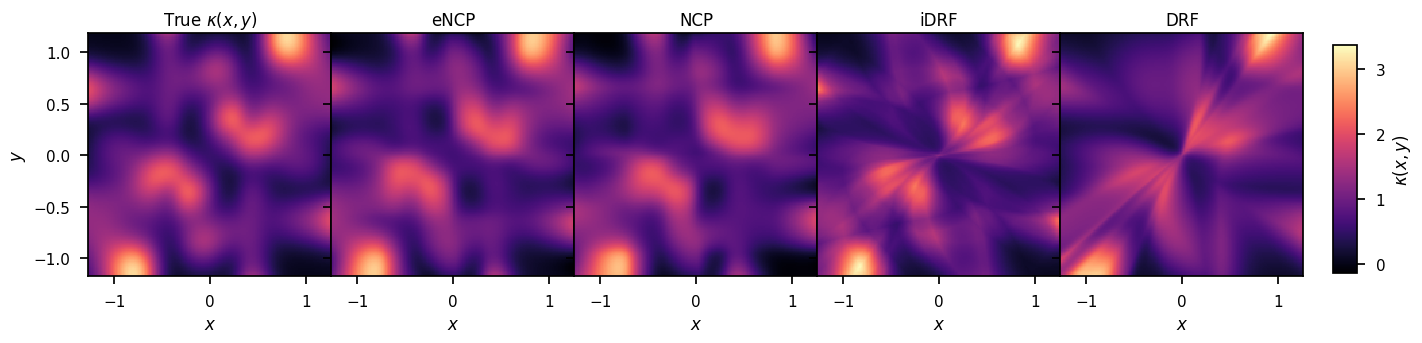

In [59]:
fig_pmd_surface, axes_pmd_surface, pmd_surface_scale = plot_pmd_surface_grid(
    error_grids_by_size,
    size_order=[MAX_TOTAL_SAMPLES],
    model_order=MODEL_ORDER,
    figsize=(3.0 * (1 + len(MODEL_ORDER)), 3),
)
plt.show()
